<a href="https://colab.research.google.com/github/api-sage/housing_price_predictor/blob/feature%2Flinear-regression/house_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
from numpy import ndarray
from typing import Callable, Dict, Tuple, List

In [6]:
np.set_printoptions(precision=4)
TEST_ALL = False

Data Importation and Loading

In [7]:
'''
from sklearn.datasets import load_boston
boston = load_boston
data = boston.data
target = boston.target
features = boston.feature_names
'''
# Boston housing data has been deprecated because of ethical issues, but I am using it for learning purpose only
import pandas as pd
pd.set_option('display.width', 1000)

features = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# Data visualization using DF
'''
df = pd.DataFrame(data, columns=features)
df['TARGET'] = target
print(df.head())
'''


"\ndf = pd.DataFrame(data, columns=features)\ndf['TARGET'] = target\nprint(df.head())\n"

Data Prep

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
s = StandardScaler()
data = s.fit_transform(data)
x_train, x_test, y_train, y_test = train_test_split(data, target, test_size=0.3, random_state=80718)
y_train, y_test = y_train.reshape(-1,1), y_test.reshape(-1,1)

In [10]:
def forward_pass(x_batch: ndarray,
                 y_batch: ndarray,
                 weights: Dict[str, ndarray]
                 ) -> Tuple[float, Dict[str, ndarray]]:

    # Forward pass algorithm for the step-by-step linear regression model

    w_batch: ndarray = weights['W']
    b_batch: ndarray = weights['B']

    # Assert that batch sizes of X and Y matrices are equal.
    # This is to ensure that all observations for training have targets.
    # That there are no missing targets.
    assert x_batch.shape[0] == y_batch.shape[0]

    #Assert that matrice multiplication can work. i.e n of x_batch == m of weights['W']
    assert x_batch.shape[1] == w_batch.shape[0]

    # Assert that B, the intersection on the dependent axis is a 1x1 array
    assert b_batch.shape[0] == b_batch.shape[1]

    # Compute the operations on the forward pass
    n: ndarray = np.dot(x_batch, w_batch)
    p: ndarray = n + b_batch

    # Finding the residuals - the loss
    loss: float = np.mean(np.square(y_batch - p))

    # Save the results from the forward pass operation
    forward_pass_result: Dict[str, ndarray] = {}
    forward_pass_result['X'] = x_batch
    forward_pass_result['N'] = n
    forward_pass_result['P'] = p
    forward_pass_result['Y'] = y_batch

    return loss, forward_pass_result


In [11]:
def loss_gradient(forward_pass_result: Dict[str, ndarray],
                  weights: Dict[str, ndarray]) -> Dict[str, ndarray]:
    # Calculating by what factor the inputs have to change for the loss value to reduce
    dLdP = -2 * (forward_pass_result['Y']-forward_pass_result['P'])
    dPdN = np.ones_like(forward_pass_result['N'])
    dPdB = np.ones_like(weights['B'])

    dLdN = dLdP * dPdN
    dLdB = (dLdP * dPdB).sum(axis=0)

    dNdW = np.transpose(forward_pass_result['X'], (1,0))
    dLdW = np.dot(dNdW, dLdN)

    # Declaring return object
    loss_gradient_result: Dict[str, ndarray] = {}
    loss_gradient_result['W'] = dLdW
    loss_gradient_result['B'] = dLdB

    return loss_gradient_result

In [12]:
def to_2d_np(a: ndarray, type="col")-> ndarray:
    # TURNS A 1D ARRAY INTO A 2D ARRAY

    assert a.ndim == 1

    if type == "col":
        return a.reshape(-1,1)
    elif type == "row":
        return a.reshape(1,-1)
    else:
        raise ValueError('type must be "col" or "row"')


In [13]:
def permute_data(x: ndarray, y: ndarray):
    # Shuffles matrix x and y stochastically

    perm = np.random.permutation(x.shape[0])
    print("Permuted Data::\n", perm)
    print("Permuted X Data::\n", x[perm])
    print("Permuted Y Data::\n", y[perm])
    return x[perm], y[perm]

In [14]:
Batch = Tuple[ndarray, ndarray]

def generate_batch(x: ndarray,
                   y: ndarray,
                   start: int = 0,
                   batch_size: int = 10) -> Batch:
    # Generates batch from x and y matrices, given a start position and batch size

    # x and y must be 2-dimensional
    assert x.ndim == y.ndim == 2

    if start + batch_size > x.shape[0]:
        batch_size = x.shape[0] - start

    x_batch, y_batch = x[start:start + batch_size], y[start:start + batch_size]

    return x_batch, y_batch

In [15]:
def init_weights(n_in: int) -> Dict[str, ndarray]:
    # Initializes weight on first forward pass model
    weights: Dict[str, ndarray] = {}
    W = np.random.randn(n_in, 1)
    B = np.random.randn(1, 1)
    weights['W'] = W
    weights['B'] = B

    return weights

In [32]:
def train(x: ndarray,
          y: ndarray,
          n_iter: int = 1000,
          learning_rate: float = 0.1,
          batch_size: int = 100,
          return_losses: bool = False,
          return_weights: bool = False,
          seed: int = 1) ->  None:
    # Train model for a certain number of epochs

    if seed:
        np.random.seed(seed)
    start = 0

    # Initialize weights
    weights = init_weights(x.shape[1])
    print("Weights:\n", weights)

    # Permute data
    x, y = permute_data(x, y)

    losses = []

    for i in range(n_iter):
        # Generate batch
        if start >= x.shape[0]:
            x, y = permute_data(x, y)
            start = 0

        x_batch, y_batch = generate_batch(x, y, start, batch_size)
        start += batch_size

        # Train using generated batch
        loss, forward_info = forward_pass(x_batch, y_batch, weights)

        print("Loss::\n", loss, "Forward Info::\n", forward_info)

        if return_losses:
          losses.append(loss)

        backward_pass = loss_gradient(forward_info, weights)

        print("Backward Pass::\n", backward_pass)

        for key in backward_pass.keys():
            weights[key] -= learning_rate * backward_pass[key]

    if return_weights:
        return losses, weights

    return None

In [35]:
train_result = train(x_train,
                     y_train,
                     n_iter=1000,
                     learning_rate=0.0001,
                     batch_size=23,
                     return_losses=True,
                     return_weights=True,
                     seed=180708)

print("Train result::\n", train_result)

Streaming output truncated to the last 5000 lines.
       [14.7224],
       [32.8498],
       [-1.008 ],
       [20.2241],
       [24.5208],
       [31.4878],
       [13.9074],
       [17.126 ],
       [16.7936],
       [11.8735],
       [ 4.4572],
       [31.8863],
       [37.1269],
       [25.3629],
       [28.154 ],
       [17.509 ],
       [10.4898],
       [23.0765],
       [26.8457]]), 'Y': array([[14.2],
       [17.4],
       [23.1],
       [29.9],
       [13.3],
       [35.4],
       [13.8],
       [18. ],
       [23.9],
       [27.5],
       [18.5],
       [20.8],
       [14.5],
       [13.4],
       [14.4],
       [32. ],
       [37.6],
       [25.2],
       [28.4],
       [22.5],
       [14.6],
       [29.6],
       [22. ]])}
Backward Pass::
 {'W': array([[ -39.266 ],
       [  38.0935],
       [ -43.0021],
       [  52.8081],
       [ -44.7791],
       [ 183.9343],
       [ -36.561 ],
       [  56.6215],
       [ -15.7485],
       [ -22.7811],
       [ -32.498 ],
       [ -

Text(0.5, 1.0, 'A Graph of Loss vs Epochs')

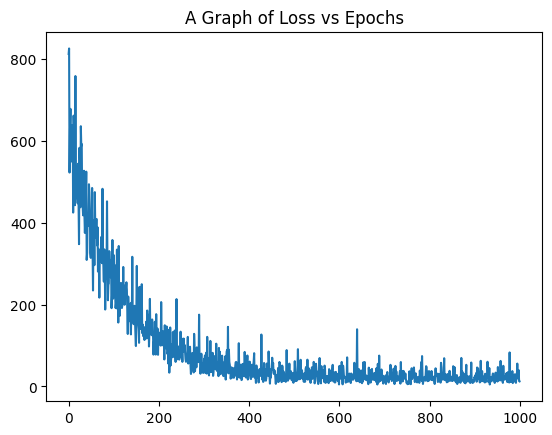

In [38]:
import matplotlib.pyplot as plt
plt.plot(list(range(1000)), train_result[0])
plt.title("A Graph of Loss vs Epochs")